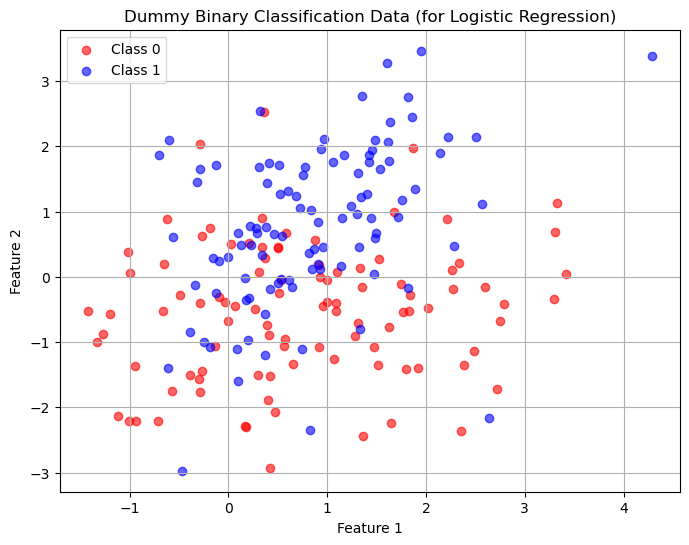

Features shape: (200, 2)
Target shape: (200,)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Set seed
np.random.seed(42)

# Generate a classification dataset
x, y = make_classification(
    n_samples=200,
    n_features=2,          # Only 2 useful features for visualization
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.8,         # Low separation makes it harder
    flip_y=0.1,            # Add noise (10% label flipping)
    random_state=42
)
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)
# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print("Features shape:", x.shape)
print("Target shape:", y.shape)

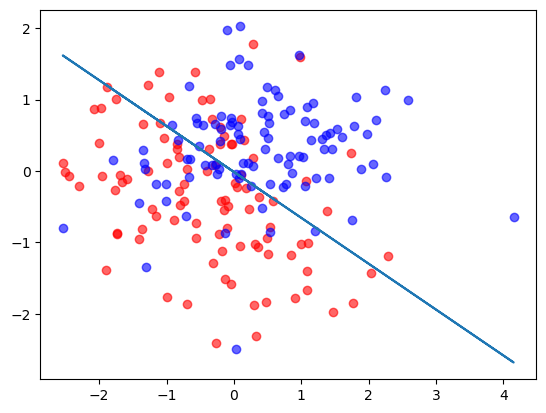

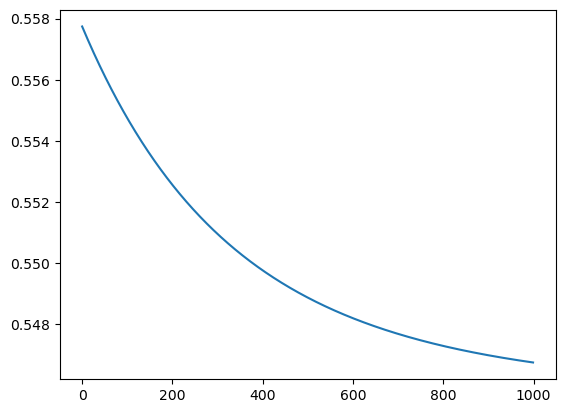

In [3]:
w = np.random.randn(1,2)
b = np.array([[0]])
#x_train = x.reshape(-1,1)
m = x_train.shape[0]
alpha = 0.01
cost_history = []
mean = np.mean(x_train, axis=0)
std = np.std(x_train, axis=0)

x_train = (x_train - mean) / std
x_test = (x_test - mean) / std
cov = np.cov(x_train.T)

eigenvalues, eigenvectors = np.linalg.eig(cov)

idx = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, idx]

k = 2
principal_components = eigenvectors[:, :k]

x_train = x_train @ principal_components
x_test = x_test @ principal_components

for i in range(1000):
   
    z = (x @w .T )+b
    y_ = 1/(1+(np.exp(-z)))
    # cost = np.mean(-(y_train)* np.log(y_)) - ((1 - y_train) * np.log(1 - y_)))
    cost = np.mean(-(y_train * np.log(y_+0.000000001)) - ((1 - y_train) * np.log(1 - y_+0.000000001)))
    cost_history.append(cost)
    
    djdw =(x.T @ (y_ - y_train)).T / m
    djdb = (np.sum(y_ - y_train)) / m
        
    w = w - alpha * djdw
    b = b - alpha * djdb

    
plt.scatter (x[y == 0][:,0],x[y==0][:,1], color="red", label= "Class 0", alpha=0.6)
plt.scatter(x[y == 1][:,0],x[y==1][:,1] , color="blue", label="Class 1", alpha=0.6)

x1 = x[:,0]
x2 =(-w[0][0]*x1-b[0][0])/w[0][1]
plt.plot(x1,x2)
plt.show()

plt.plot(cost_history)
plt.show()
    
    
                     

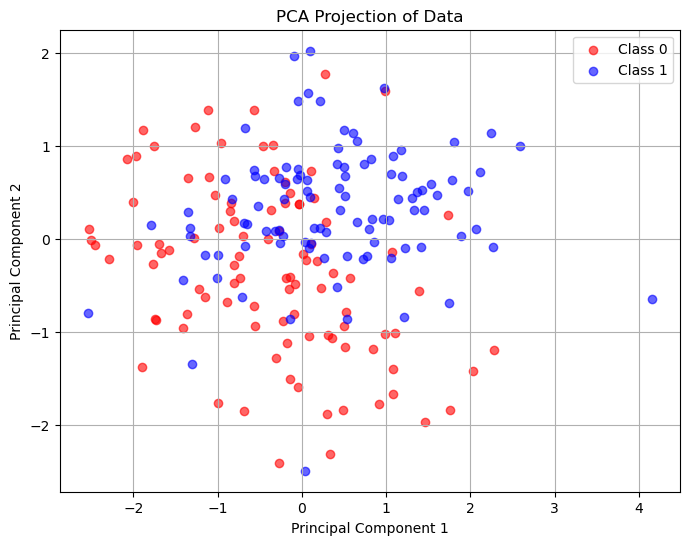

In [4]:
plt.figure(figsize=(8,6))

plt.scatter(
    x[y==0][:,0],
    x[y==0][:,1],
    color='red',
    label='Class 0',
    alpha=0.6
)

plt.scatter(
    x[y==1][:,0],
    x[y==1][:,1],
    color='blue',
    label='Class 1',
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Data")
plt.legend()
plt.grid(True)
plt.show()